In [1]:
import tensorflow as tf

2026-01-31 12:52:13.540766: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-31 12:52:13.573681: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-31 12:52:14.352281: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
!wget https://raw.githubusercontent.com/lazyprogrammer/machine_learning_examples/master/tf2.0/moore.csv

--2026-01-31 12:52:15--  https://raw.githubusercontent.com/lazyprogrammer/machine_learning_examples/master/tf2.0/moore.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2302 (2.2K) [text/plain]
Saving to: ‘moore.csv.1’

moore.csv.1         100%[===================>]   2.25K  --.-KB/s    in 0s      

2026-01-31 12:52:15 (85.9 MB/s) - ‘moore.csv.1’ saved [2302/2302]



In [4]:
!head moore.csv

1971,2300
1972,3500
1973,2500
1973,2500
1974,4100
1974,4500
1974,8000
1975,3510
1976,5000
1976,8500


In [5]:
data=pd.read_csv('moore.csv',header=None).to_numpy()

In [6]:
data

array([[       1971,        2300],
       [       1972,        3500],
       [       1973,        2500],
       [       1973,        2500],
       [       1974,        4100],
       [       1974,        4500],
       [       1974,        8000],
       [       1975,        3510],
       [       1976,        5000],
       [       1976,        8500],
       [       1976,        6500],
       [       1978,        9000],
       [       1978,       29000],
       [       1979,       17500],
       [       1979,       29000],
       [       1979,       68000],
       [       1981,       11500],
       [       1982,       55000],
       [       1982,      134000],
       [       1983,       22000],
       [       1984,       63000],
       [       1984,      190000],
       [       1985,      275000],
       [       1985,       25000],
       [       1985,       16000],
       [       1986,      110000],
       [       1986,      375000],
       [       1986,       30000],
       [       1987,

In [7]:
X=data[:,0].reshape(-1,1)
y=data[:,1]

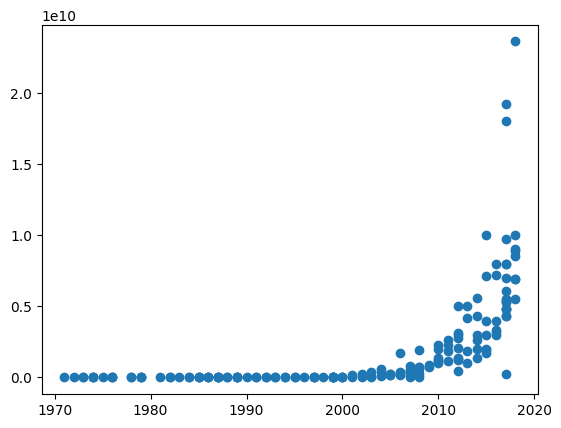

In [8]:
plt.scatter(X,y);

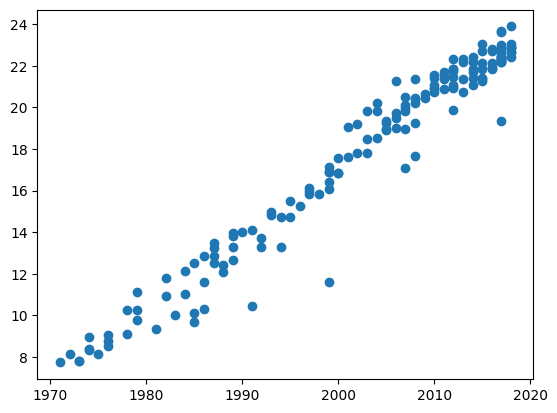

In [9]:
Y=np.log(y)
plt.scatter(X,Y);

In [10]:
X=X-X.mean()

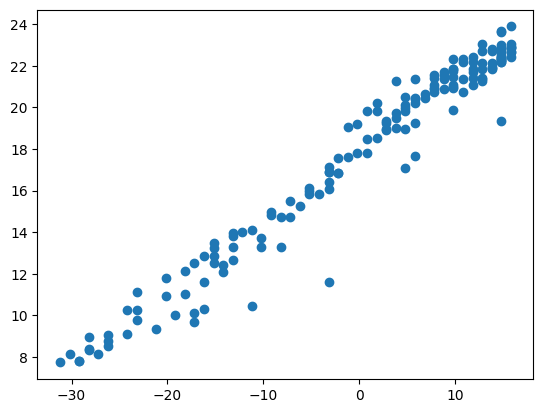

In [11]:
plt.scatter(X,Y);

In [12]:
model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1),
])

I0000 00:00:1769845936.223001  240499 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3898 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


In [13]:
model.compile(optimizer=tf.keras.optimizers.SGD(0.001,0.9),loss='mse')

In [14]:
def schedule(epoch,lr):
    if epoch%10==0 and epoch!=0:
        return 0.8*lr
    return lr

scheduler=tf.keras.callbacks.LearningRateScheduler(schedule)

In [15]:

r=model.fit(X,Y,epochs=200,callbacks=[scheduler])

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 320.2903 - learning_rate: 0.0010
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 287.8596 - learning_rate: 0.0010
Epoch 3/200
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 249.9332

2026-01-31 12:52:16.918133: I external/local_xla/xla/service/service.cc:163] XLA service 0x75aed0016a90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-31 12:52:16.918152: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 SUPER, Compute Capability 7.5
2026-01-31 12:52:16.940652: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801
I0000 00:00:1769845936.994526  240655 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 260.5569 - learning_rate: 0.0010
Epoch 4/200
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 210.9343 - learning_rate: 0.0010
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 151.4224 - learning_rate: 0.0010
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 115.5157 - learning_rate: 0.0010
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 84.4833 - learning_rate: 0.0010
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 63.5668 - learning_rate: 0.0010
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 46.1676 - learning_rate: 0.0010
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37.9248 - learning_rate: 0.0010
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 28.5479 - learning_rate: 8.0000e-04
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 27.9357 - learning_rate: 8.0000e-04
Epoch 13/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20.2798 - learning_rate: 8.0000e-04
E

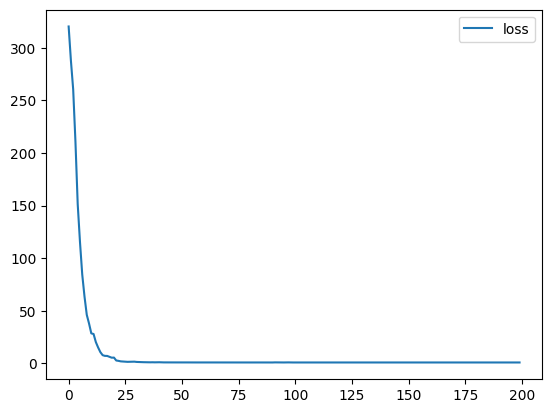

In [16]:
plt.plot(r.history['loss'],label='loss')
plt.legend()
plt.show();

In [17]:
model.layers

[<Dense name=dense, built=True>]

In [18]:
model.layers[0].get_weights()

[array([[0.34042808]], dtype=float32), array([17.750126], dtype=float32)]

In [19]:
a=model.layers[0].get_weights()[0][0,0]
b=model.layers[0].get_weights()[1][0]
a,b

(np.float32(0.34042808), np.float32(17.750126))

In [20]:
np.log(2)/a

np.float64(2.03610457792007)

In [21]:
X=X.flatten()
denom = X.dot(X) -X.mean()*X.sum()
a=(X.dot(Y) - Y.mean()*X.sum())/denom
b=(Y.mean()*X.dot(X) - X.mean()*X.dot(Y))/denom
a,b

(np.float64(0.341682487387313), np.float64(17.764939393631764))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


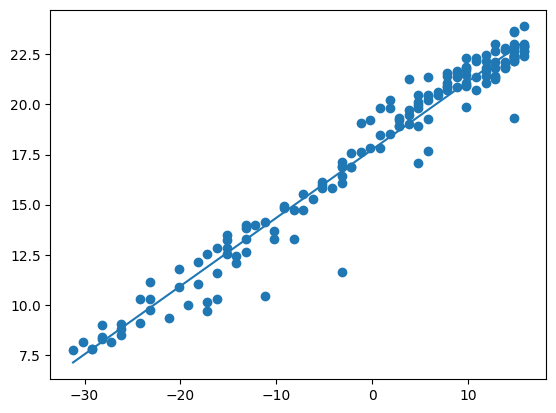

In [22]:
Yhat=model.predict(X).flatten()
plt.scatter(X,Y)
plt.plot(X,Yhat);

In [23]:
w,b=model.layers[0].get_weights()
X=X.reshape(-1,1)
Yhat2=(X.dot(w)+b).flatten()
np.allclose(Yhat,Yhat2)

True